# Intrinsic Jacobian analysis of a curated cell-cycle expression panel

This notebook provides a second real-data application of ManfitVelo and the intrinsic-Jacobian toolkit. The dataset contains 2,793 cells measured over 33 curated cell-cycle genes, RNA velocities in the same coordinates, and a two-dimensional FlowMap embedding for visualization.

The supplied `relativePos` variable is an independently measured, protein-derived continuous cell-cycle state and is therefore used as an external ordering variable. It is not treated as an inferred RNA phase label. Because no categorical phase boundaries are supplied, the notebook shows descriptive trends along this ordering without checkpoint tests or phase-wise significance testing. The exact protein channel, assay platform, and primary citation should be added to the data provenance record before publication.

## 1. Setup and data

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

ROOT = Path.cwd().resolve()
if not (ROOT / 'intrinsic_jacobian.py').exists():
    raise RuntimeError('Start Jupyter from the application_intrinsic jacobian directory.')
MANFITVELO_ROOT = ROOT.parent
for path in (ROOT, MANFITVELO_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from scripts.velocity_manifold_fitter import VelocityManifoldFitter
from intrinsic_jacobian import estimate_jacobian_field
from connection_smoothing import connection_aware_smooth
from downstream_geometry import (
    acceleration_decomposition, strain_rotation_decomposition,
    find_fixed_point_candidates, refine_fixed_point, classify_fixed_point,
)

warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*encountered in matmul.*')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
DATA_DIR = ROOT / 'datasets' / 'cell_cycle'
K_GEOM, T_ITERS, SEED, LAMBDA_J = 30, 5, 0, 1.0

X_raw = np.load(DATA_DIR / 'X_cc.npy')
V_raw = np.load(DATA_DIR / 'V_cc.npy')
embedding = np.load(DATA_DIR / 'flowmap_embedding.npy')
protein_cycle_position = np.load(DATA_DIR / 'color_cell_cycle_relativePos.npy')
genes = np.array((DATA_DIR / 'genes_cc.txt').read_text().splitlines())
assert X_raw.shape == V_raw.shape == (len(embedding), len(genes))
assert protein_cycle_position.shape == (len(X_raw),)
assert np.isfinite(X_raw).all() and np.isfinite(V_raw).all() and np.isfinite(protein_cycle_position).all()
pd.Series({
    'cells': len(X_raw), 'genes': len(genes), 'embedding dimensions': embedding.shape[1],
    'protein cycle-state range': f'{protein_cycle_position.min():.3f}–{protein_cycle_position.max():.3f}',
})

cells                               2793
genes                                 33
embedding dimensions                   2
protein cycle-state range    0.013–1.000
dtype: object

## 2. ManfitVelo → intrinsic Jacobian → connection smoothing

The full analysis is run at `d=1` and `d=2`. The FlowMap embedding is used only for display; fitting and Jacobian estimation use the 33-dimensional expression/velocity coordinates.

In [2]:
def fit_dimension(X, V, d):
    fitter = VelocityManifoldFitter(
        X, V, d_mode='global', global_d=d, k=K_GEOM, T=T_ITERS,
        eta_g=.7, theta=.02, kappa=0., bandwidth_mode='variable',
        use_PCA=False, random_state=SEED, lambda_v=1.,
        velocity_covariance_mode='uncentered',
        velocity_trace_normalization='match_position_trace',
    )
    source = fitter.fit(update_mode='normal_only', return_dict=True)
    field = estimate_jacobian_field(
        source['X'], source['V'], np.asarray(source['U']), source['P'], d,
        k0=source['neighbors'].shape[1],
    )
    raw_geometry = strain_rotation_decomposition(field.J_intrinsic)
    smooth = connection_aware_smooth(
        field.J_intrinsic, np.asarray(source['U']), source['neighbors'], source['weights'],
        field.n_eff, field.kappa_intrinsic, field.residual_intrinsic,
        lambda_J=LAMBDA_J, abstained=field.abstained,
    )
    if smooth.cg_info != 0:
        raise RuntimeError(f'CG did not converge for d={d}: info={smooth.cg_info}')
    return {
        'source': source, 'field': field, 'raw': raw_geometry, 'smooth': smooth,
        'geometry': strain_rotation_decomposition(smooth.J_smoothed),
        'acceleration': acceleration_decomposition(field.J_amb, field.N, source['V'], source['P']),
    }

fits = {d: fit_dimension(X_raw, V_raw, d) for d in (1, 2)}
pd.DataFrame({d: {
    'reliable fraction': fits[d]['field'].reliable.mean(),
    'median n_eff': np.nanmedian(fits[d]['field'].n_eff),
    'median condition number': np.nanmedian(fits[d]['field'].kappa_intrinsic),
    'CG iterations': fits[d]['smooth'].n_iter,
} for d in (1, 2)}).T.rename_axis('intrinsic dimension')

,reliable fraction,median n_eff,median condition number,CG iterations
intrinsic dimension,,,,
1,0.798783,18.606582,1.000000,40.0
2,0.617615,18.683500,1.748233,46.0


## 3. Local flow geometry

Divergence describes local expansion or contraction of neighboring state-space trajectories. In `d=2`, shear captures direction-dependent stretching and rotation magnitude captures the local cyclic component. These are properties of the inferred expression-state flow, not population growth, cell death, or physical rotation.

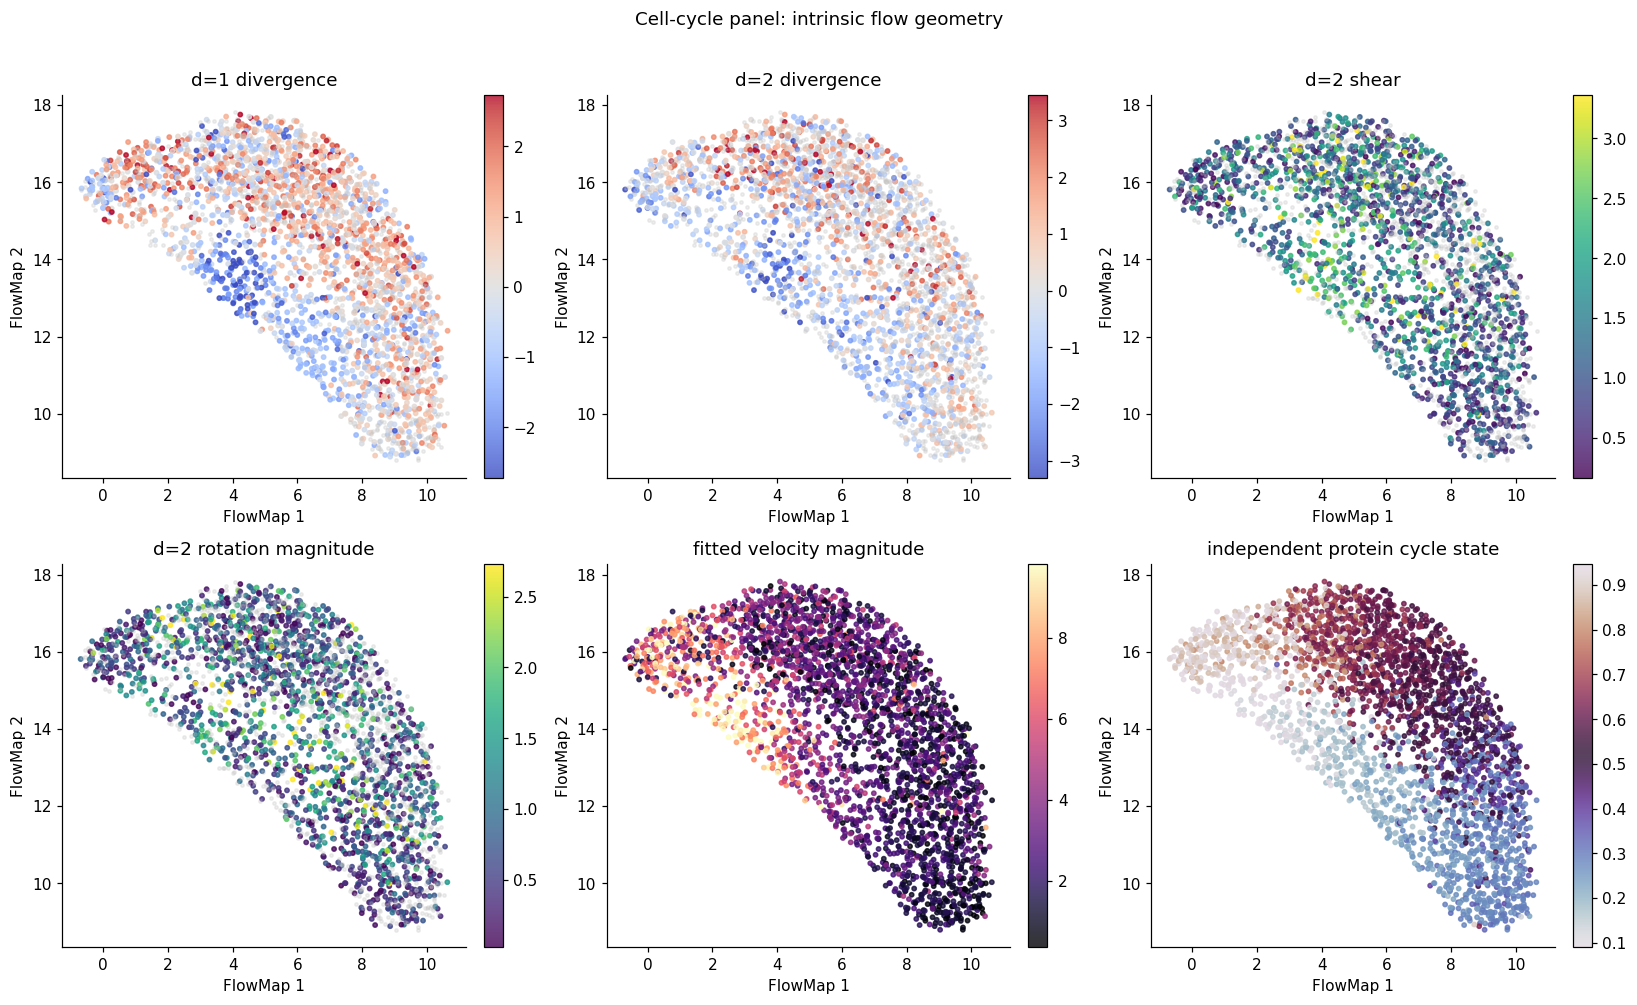

In [3]:
fit1, fit2 = fits[1], fits[2]
speed = np.linalg.norm(fit2['source']['V'], axis=1)
geometry_panels = [
    (fit1['geometry'].divergence, 'coolwarm', 'd=1 divergence', fit1['field'].reliable),
    (fit2['geometry'].divergence, 'coolwarm', 'd=2 divergence', fit2['field'].reliable),
    (fit2['geometry'].shear, 'viridis', 'd=2 shear', fit2['field'].reliable),
    (fit2['geometry'].vorticity_mag, 'viridis', 'd=2 rotation magnitude', fit2['field'].reliable),
    (speed, 'magma', 'fitted velocity magnitude', None),
    (protein_cycle_position, 'twilight', 'independent protein cycle state', None),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
# Unreliable/abstained cells are excluded from the percentile scale and the
# colored scatter, and shown as light gray instead -- consistent with the
# Gauss-decomposition panels below, so a noisy or ill-conditioned local fit
# never silently shapes the color scale or reads as signal in this figure.
for ax, (values, cmap, title, reliable_mask) in zip(axes.ravel(), geometry_panels):
    if reliable_mask is None:
        lo, hi = np.nanpercentile(values, [2, 98])
        shown = np.clip(values, lo, hi)
        artist = ax.scatter(embedding[:, 0], embedding[:, 1], c=shown, cmap=cmap, s=8, alpha=.8)
    else:
        lo, hi = np.nanpercentile(values[reliable_mask], [2, 98])
        shown = np.clip(values, lo, hi)
        artist = ax.scatter(embedding[reliable_mask, 0], embedding[reliable_mask, 1],
                             c=shown[reliable_mask], cmap=cmap, s=8, alpha=.8)
        ax.scatter(embedding[~reliable_mask, 0], embedding[~reliable_mask, 1], s=5, color='.75', alpha=.25)
    ax.set(title=title, xlabel='FlowMap 1', ylabel='FlowMap 2')
    fig.colorbar(artist, ax=ax, fraction=.046, pad=.04)
fig.suptitle('Cell-cycle panel: intrinsic flow geometry', y=1.01)
fig.tight_layout(); plt.show()

## 4. Gauss decomposition

The ambient change in velocity is decomposed as

$$D_vv = a_{\mathrm{int}} + a_{\mathrm{normal}}.$$

`a_int` describes change of the transcriptional flow within the fitted state manifold. `a_normal` describes ambient direction change induced by bending of that manifold. The bending ratio compares their magnitudes. All three are relative to the learned manifold in the 33-gene coordinate space; they are not physical forces or direct regulatory coefficients.

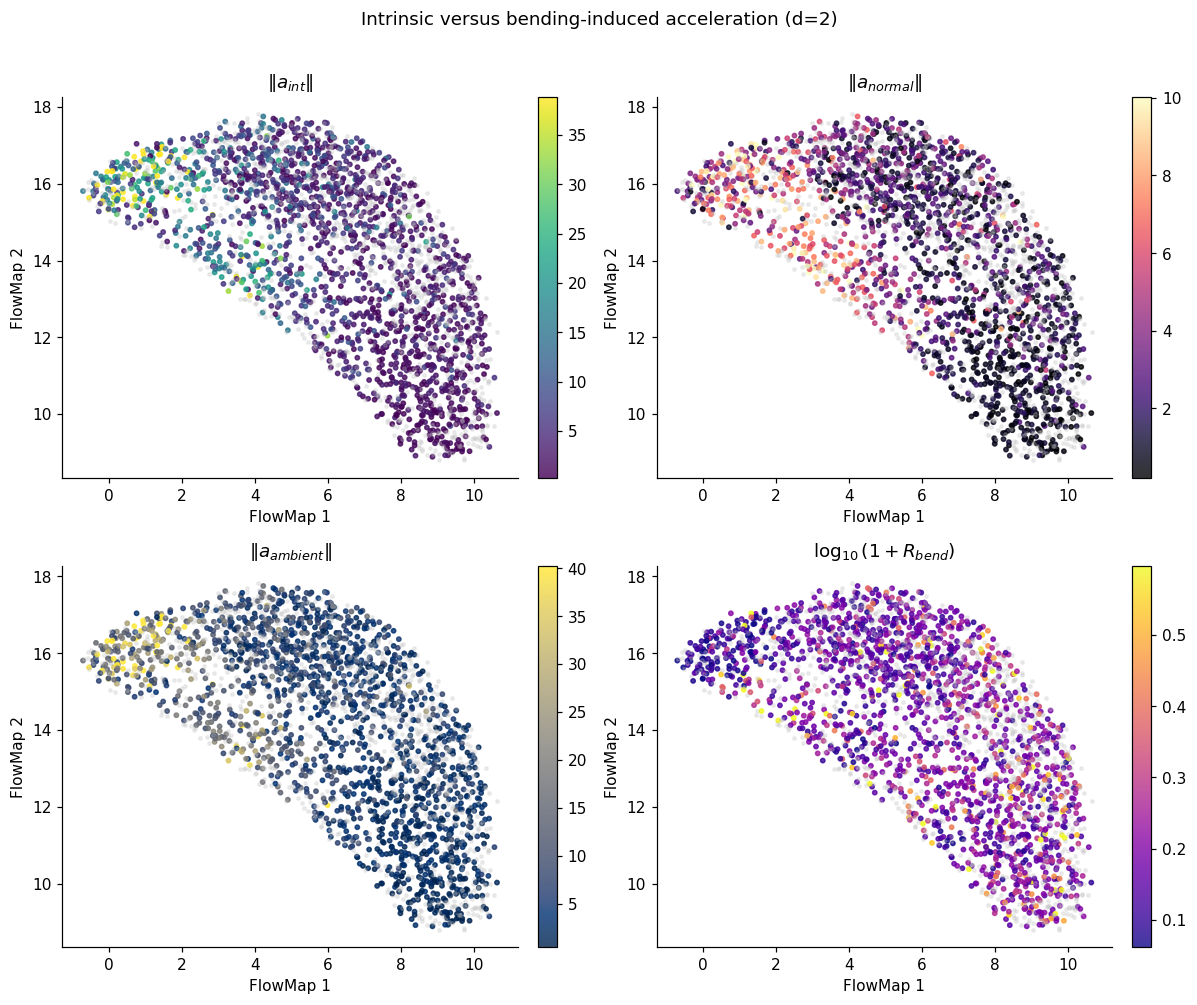

In [4]:
gauss = fit2['acceleration']; gauss_ok = fit2['field'].reliable
a_int_norm = np.linalg.norm(gauss.a_int, axis=1)
a_normal_norm = np.linalg.norm(gauss.a_normal, axis=1)
a_ambient_norm = np.linalg.norm(gauss.a_amb, axis=1)
log_ratio = np.log10(1 + gauss.R_bend)
relative_error = np.linalg.norm(gauss.a_amb - gauss.a_int - gauss.a_normal, axis=1)
relative_error /= a_ambient_norm + a_int_norm + a_normal_norm + 1e-12
pd.Series({
    'reliable cells': int(gauss_ok.sum()),
    'max relative decomposition error': np.nanmax(relative_error[gauss_ok]),
    'median ||a_intrinsic||': np.nanmedian(a_int_norm[gauss_ok]),
    'median ||a_normal||': np.nanmedian(a_normal_norm[gauss_ok]),
    'median R_bend': np.nanmedian(gauss.R_bend[gauss_ok]),
})

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (values, cmap, title) in zip(axes.ravel(), [
    (a_int_norm, 'viridis', r'$\|a_{int}\|$'),
    (a_normal_norm, 'magma', r'$\|a_{normal}\|$'),
    (a_ambient_norm, 'cividis', r'$\|a_{ambient}\|$'),
    (log_ratio, 'plasma', r'$\log_{10}(1+R_{bend})$'),
]):
    lo, hi = np.nanpercentile(values[gauss_ok], [2, 98]); shown = np.clip(values, lo, hi)
    artist = ax.scatter(embedding[gauss_ok, 0], embedding[gauss_ok, 1],
                         c=shown[gauss_ok], cmap=cmap, s=8, alpha=.8)
    ax.scatter(embedding[~gauss_ok, 0], embedding[~gauss_ok, 1], s=5, color='.75', alpha=.25)
    ax.set(title=title, xlabel='FlowMap 1', ylabel='FlowMap 2')
    fig.colorbar(artist, ax=ax, fraction=.046, pad=.04)
fig.suptitle('Intrinsic versus bending-induced acceleration (d=2)', y=1.01)
fig.tight_layout(); plt.show()

## 5. Geometry along the independent protein cycle state

The protein-derived state supplies an external continuous ordering of the cells. The curves below are equal-width-bin medians; shading shows the interquartile range. They are descriptive summaries rather than fitted trajectories. In particular, no phase boundaries, checkpoint locations, or p-values are inferred from these curves.

The first panel asks whether local expansion/contraction changes coherently along the independently measured cycle. The second separates change of velocity within the expression manifold (`a_int`) from direction change associated with manifold bending (`a_normal`). The third shows their relative balance through $R_{bend}=\|a_{normal}\|/(\|a_{int}\|+\epsilon)$.

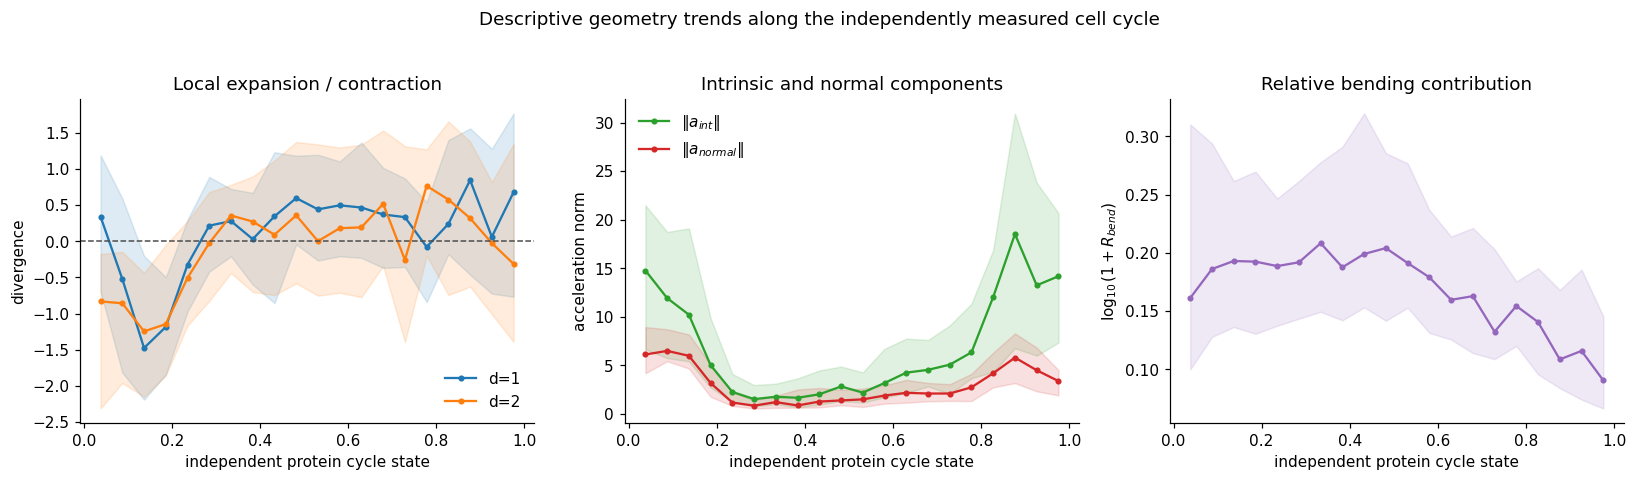

In [5]:
def binned_median_iqr(position, values, valid, n_bins=20):
    edges = np.linspace(position.min(), position.max(), n_bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    bin_id = np.clip(np.digitize(position, edges) - 1, 0, n_bins - 1)
    summary = np.full((n_bins, 3), np.nan)
    for b in range(n_bins):
        selected = valid & (bin_id == b) & np.isfinite(values)
        if selected.any():
            summary[b] = np.percentile(values[selected], [50, 25, 75])
    return centers, summary

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
trend_panels = [
    axes[0], axes[1], axes[2],
]
for values, valid, label, color in [
    (fit1['geometry'].divergence, fit1['field'].reliable, 'd=1', 'tab:blue'),
    (fit2['geometry'].divergence, fit2['field'].reliable, 'd=2', 'tab:orange'),
]:
    centers, summary = binned_median_iqr(protein_cycle_position, values, valid)
    axes[0].plot(centers, summary[:, 0], marker='o', ms=3, label=label, color=color)
    axes[0].fill_between(centers, summary[:, 1], summary[:, 2], color=color, alpha=.14)
axes[0].axhline(0, color='.3', lw=1, ls='--')
axes[0].set(ylabel='divergence', title='Local expansion / contraction')
axes[0].legend(frameon=False)
for values, label, color in [
    (a_int_norm, r'$\|a_{int}\|$', 'tab:green'),
    (a_normal_norm, r'$\|a_{normal}\|$', 'tab:red'),
]:
    centers, summary = binned_median_iqr(protein_cycle_position, values, gauss_ok)
    axes[1].plot(centers, summary[:, 0], marker='o', ms=3, label=label, color=color)
    axes[1].fill_between(centers, summary[:, 1], summary[:, 2], color=color, alpha=.14)
axes[1].set(ylabel='acceleration norm', title='Intrinsic and normal components')
axes[1].legend(frameon=False)
centers, summary = binned_median_iqr(protein_cycle_position, log_ratio, gauss_ok)
axes[2].plot(centers, summary[:, 0], marker='o', ms=3, color='tab:purple')
axes[2].fill_between(centers, summary[:, 1], summary[:, 2], color='tab:purple', alpha=.14)
axes[2].set(ylabel=r'$\log_{10}(1+R_{bend})$', title='Relative bending contribution')
for ax in axes:
    ax.set_xlabel('independent protein cycle state')
fig.suptitle('Descriptive geometry trends along the independently measured cell cycle', y=1.03)
fig.tight_layout(); plt.show()

## 6. Candidate fixed points

Reliable local minima of fitted velocity magnitude are treated as fixed-point candidates. The full intrinsic-Jacobian eigenvalues classify their local flow. A capped Newton step is retained only as a trust-region diagnostic; the figure shows observed candidate cells, not extrapolated zero-velocity coordinates.

53 candidates; step capped for 41.5%
kind: {'saddle': 21, 'attractor': 21, 'repeller': 11}
motion: {'node': 36, 'spiral': 17}


,cell index,speed,kind,motion,eigenvalues,step capped
0,1670,0.067123,saddle,node,"2.37+0.00i, -3.80+0.00i",False
1,2419,0.102779,saddle,node,"-3.10+0.00i, 3.48+0.00i",False
2,2678,0.104261,saddle,node,"-1.86+0.00i, 2.26+0.00i",False
3,1568,0.145997,saddle,node,"2.99+0.00i, -1.82+0.00i",False
4,159,0.164212,saddle,node,"1.02+0.00i, -0.73+0.00i",False
5,190,0.169559,attractor,node,"-1.74+0.00i, -0.41+0.00i",False
6,514,0.176057,attractor,spiral,"-0.32+0.71i, -0.32-0.71i",False
7,1550,0.189595,attractor,spiral,"-1.10+0.21i, -1.10-0.21i",True
8,417,0.192826,attractor,node,"-2.73+0.00i, -0.81+0.00i",False
9,469,0.210839,attractor,spiral,"-1.28+0.70i, -1.28-0.70i",False


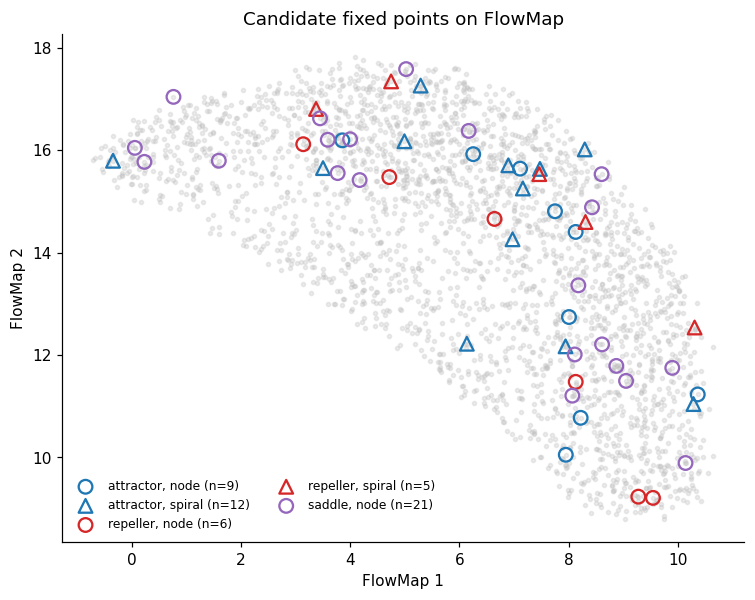

In [6]:
source, field = fit2['source'], fit2['field']
candidate_indices = find_fixed_point_candidates(source['V'], source['neighbors'], field.reliable)
fixed_rows = []
for cell_index in candidate_indices:
    neighbor_index = source['neighbors'][cell_index]
    local_scale = float(np.mean(np.linalg.norm(source['X'][neighbor_index] - source['X'][cell_index], axis=1)))
    refinement = refine_fixed_point(source['X'][cell_index], source['V'][cell_index],
                                    source['U'][cell_index], field.J_intrinsic[cell_index], local_scale)
    classification = classify_fixed_point(field.J_intrinsic[cell_index])
    fixed_rows.append({
        'cell index': int(cell_index), 'speed': np.linalg.norm(source['V'][cell_index]),
        'kind': classification.kind, 'motion': classification.motion,
        'eigenvalues': ', '.join(f'{z.real:.2f}{z.imag:+.2f}i' for z in classification.eigenvalues),
        'step capped': refinement.step_capped,
    })
fixed_points = pd.DataFrame(fixed_rows).sort_values('speed').reset_index(drop=True)
print(f'{len(fixed_points)} candidates; step capped for {fixed_points["step capped"].mean():.1%}')
print('kind:', fixed_points.kind.value_counts().to_dict())
print('motion:', fixed_points.motion.value_counts().to_dict())
display(fixed_points.head(15))

colors = {'attractor': 'tab:blue', 'repeller': 'tab:red', 'saddle': 'tab:purple'}
markers = {'node': 'o', 'spiral': '^'}
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(embedding[:, 0], embedding[:, 1], s=7, color='.75', alpha=.3)
for (kind, motion), group in fixed_points.groupby(['kind', 'motion']):
    ii = group['cell index'].to_numpy(dtype=int)
    ax.scatter(embedding[ii, 0], embedding[ii, 1], s=80, facecolors='none',
               edgecolors=colors[kind], marker=markers[motion], linewidths=1.5,
               label=f'{kind}, {motion} (n={len(ii)})')
ax.set(title='Candidate fixed points on FlowMap', xlabel='FlowMap 1', ylabel='FlowMap 2')
ax.legend(frameon=False, fontsize=8, ncol=2); plt.show()

## 7. Exploratory geometry-stratified gene ranking

The continuous protein measurement does not provide categorical phase boundaries, so a FUCCI-style phase DEG analysis is not imposed. Instead, genes are ranked descriptively by their Spearman correlation with smoothed `d=2` divergence; the table also shows the median expression difference between the highest and lowest 20% of reliable divergence values.

This is an exploratory association summary, **not an independent DEG test**: the same 33-gene expression matrix contributes to manifold/Jacobian estimation and is ranked below. No p-values or multiple-testing claims are reported.

In [7]:
divergence = fit2['geometry'].divergence; reliable = field.reliable
low_cut, high_cut = np.quantile(divergence[reliable], [.2, .8])
contracting = reliable & (divergence <= low_cut)
expanding = reliable & (divergence >= high_cut)
rows = []
for gene_index, gene in enumerate(genes):
    rho = spearmanr(X_raw[reliable, gene_index], divergence[reliable]).statistic
    rows.append({
        'gene': gene, 'median expanding': np.median(X_raw[expanding, gene_index]),
        'median contracting': np.median(X_raw[contracting, gene_index]),
        'median difference': np.median(X_raw[expanding, gene_index]) - np.median(X_raw[contracting, gene_index]),
        'Spearman with divergence': rho,
    })
geometry_de = pd.DataFrame(rows)
geometry_de = geometry_de.iloc[np.argsort(-np.abs(geometry_de['Spearman with divergence']))].reset_index(drop=True)
print(f'expanding n={expanding.sum()}, contracting n={contracting.sum()}')
geometry_de.head(20).style.format({
    'median expanding': '{:.3f}', 'median contracting': '{:.3f}', 'median difference': '{:.3f}',
    'Spearman with divergence': '{:.3f}',
})

expanding n=345, contracting n=345


,gene,median expanding,median contracting,median difference,Spearman with divergence
0,CDC20,-0.065,0.311,-0.376,-0.178
1,ATAD2,0.220,-0.048,0.268,0.165
2,CDK1,0.288,-0.630,0.918,0.161
3,AURKB,0.374,-0.078,0.452,0.158
4,CDCA3,-0.035,0.190,-0.225,-0.135
5,JPT1,-0.066,0.152,-0.218,-0.125
6,TOP2A,0.426,0.002,0.424,0.121
7,NUF2,0.247,-0.004,0.251,0.118
8,TUBB4B,0.073,0.220,-0.148,-0.112
9,TPX2,0.070,0.282,-0.211,-0.100


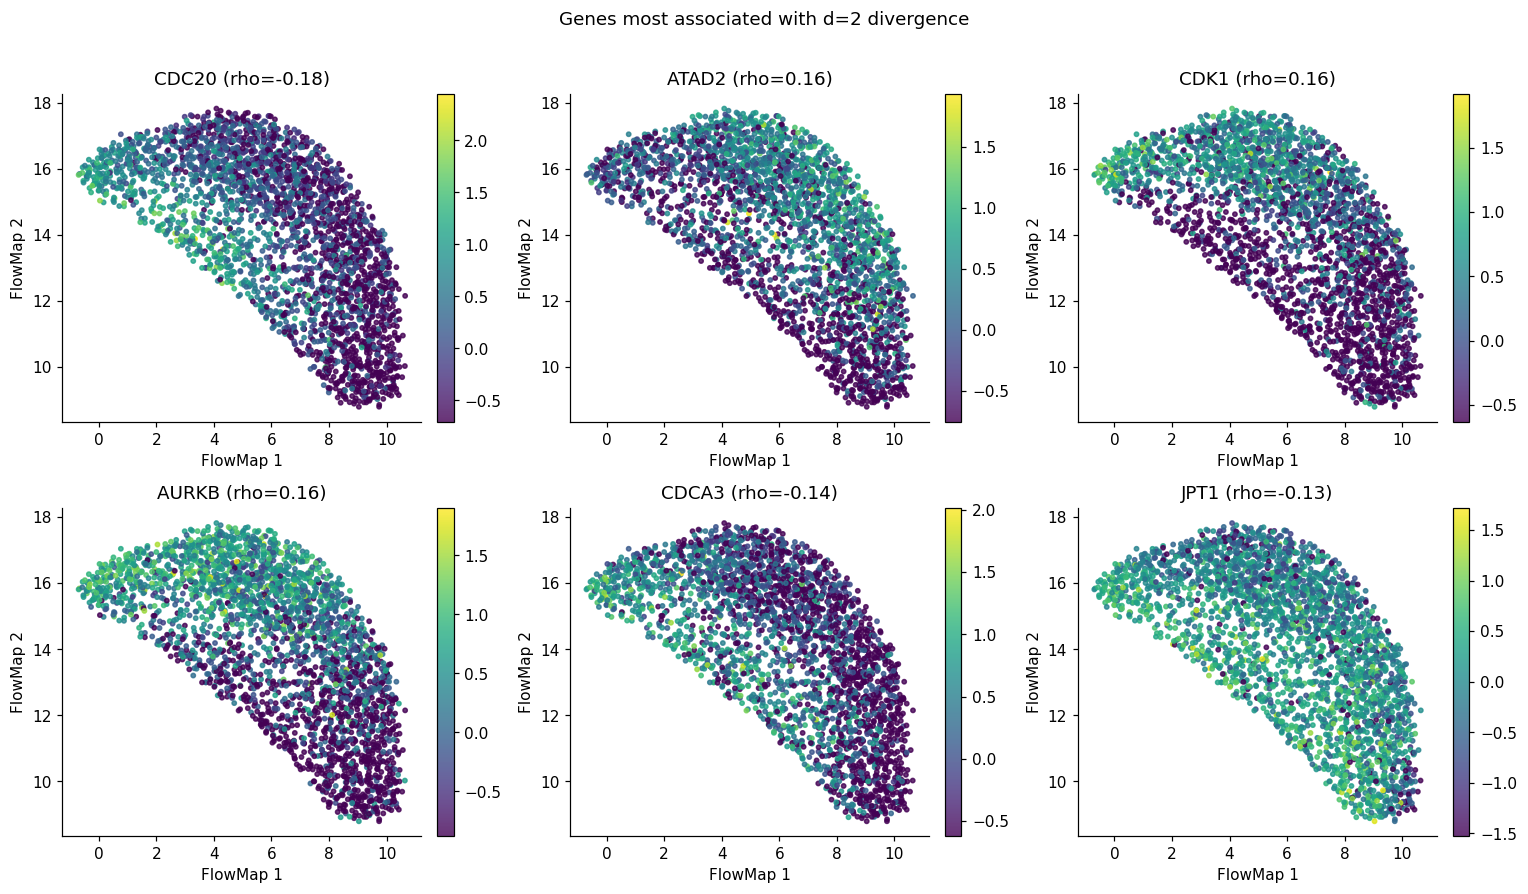

In [8]:
top_genes = geometry_de.head(6)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
gene_lookup = {gene: i for i, gene in enumerate(genes)}
for ax, (_, row) in zip(axes.ravel(), top_genes.iterrows()):
    values = X_raw[:, gene_lookup[row.gene]]
    artist = ax.scatter(embedding[:, 0], embedding[:, 1], c=values, cmap='viridis', s=8, alpha=.8)
    ax.set_title(f"{row.gene} (rho={row['Spearman with divergence']:.2f})")
    ax.set(xlabel='FlowMap 1', ylabel='FlowMap 2')
    fig.colorbar(artist, ax=ax, fraction=.046, pad=.04)
fig.suptitle('Genes most associated with d=2 divergence', y=1.01)
fig.tight_layout(); plt.show()

**Reading the gene-ranking result.** Canonical cell-cycle genes including `CDC20`, `ATAD2`, `CDK1`, `AURKB`, `TOP2A`, `NUF2`, `MCM7`, and `UBE2C` appear among the strongest associations. However, the effect sizes are modest (the largest absolute Spearman correlation is approximately 0.18). The value of this section is to identify candidate expression programs associated with the inferred geometry, not to declare statistically validated DEGs.

## 8. Interpretation boundaries

This application demonstrates that the same estimator, smoothing, Gauss decomposition, and fixed-point machinery run on a second cell-cycle dataset with a distinct 33-gene representation and FlowMap visualization. The gene table identifies expression programs associated with geometry-defined expansion and contraction states.

The independently measured protein-derived cycle state provides external biological ordering, so concordant geometry trends are evidence beyond an RNA-only visualization. The notebook still does **not** claim categorical phase discovery, checkpoint validation, or independently validated DEGs: phase boundaries were not supplied, and the curated 33-gene expression matrix is reused for fitting and gene ranking. The FUCCI notebook remains the stronger setting for formal phase-wise DEG analysis because it has independent categorical labels and a 2,000-HVG expression matrix.